## Introduction

- Clustering is a technique from the field of machine learning that helps to identify patterns in large amount of data.
- Since these patterns are not known in beforehand but rather are detected by the algorithm during the _training_ or _fitting_ phase, clustering belongs to the group of _unsupervised learning_ techniques.
- A specific, very popular and well-known method is _k-means_ clustering.
- Another increasingly popular method is _DBSCAN_, which stands for _density based spatial clustering of applications with noise_.  #TODO: - cite  original 1996 source paper “A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise” by M. Ester et al.
- Despite the former, for DBSCAN, the number of clusters does not need to be specified as an input to the algorithm.
- Instead, a distance-based threshold and a minimum cluster size has to be specified.

- To really understand how things work, I like to implement basic examples on the green field, not using specific libraries (such as sklearn for this example), to solve a toy problem.

## The Data

- data must be purely numeric (later, we will discuss briefly how to handle, e.g., categorical data)
- for the distance calculation, all features should ideally be of the same magnitude, so that no single feature is dominating the others, or that no single feature vanished, respectively.
- To achieve this, data should be normalized or standardized before performing the actual processing. 
- However, this is true for a lot of algorithms and not specific to clustering or even DBSCAN.

- For demonstration purposes, we use the iris dataset since it has only 4 features and thus it is easier to understand and get some better insights, for instance, it's easy to plot all the data in a single graph without loosing track of all the information.

## Implementing DBSCAN

### Preface

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load and prepare the data

- we load the iris dataset as provided by the seaborn library and select all the numeric columns

In [31]:
df = sns.load_dataset("iris")
df = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

- first, we need to normalize the data using a standardization scaler:

In [ ]:
df = (df - df.mean(axis=0)) / df.std(axis=0)

- a first inspection of the data already reveals some clues about possible clusters that could be identified by a clustering algorithm:

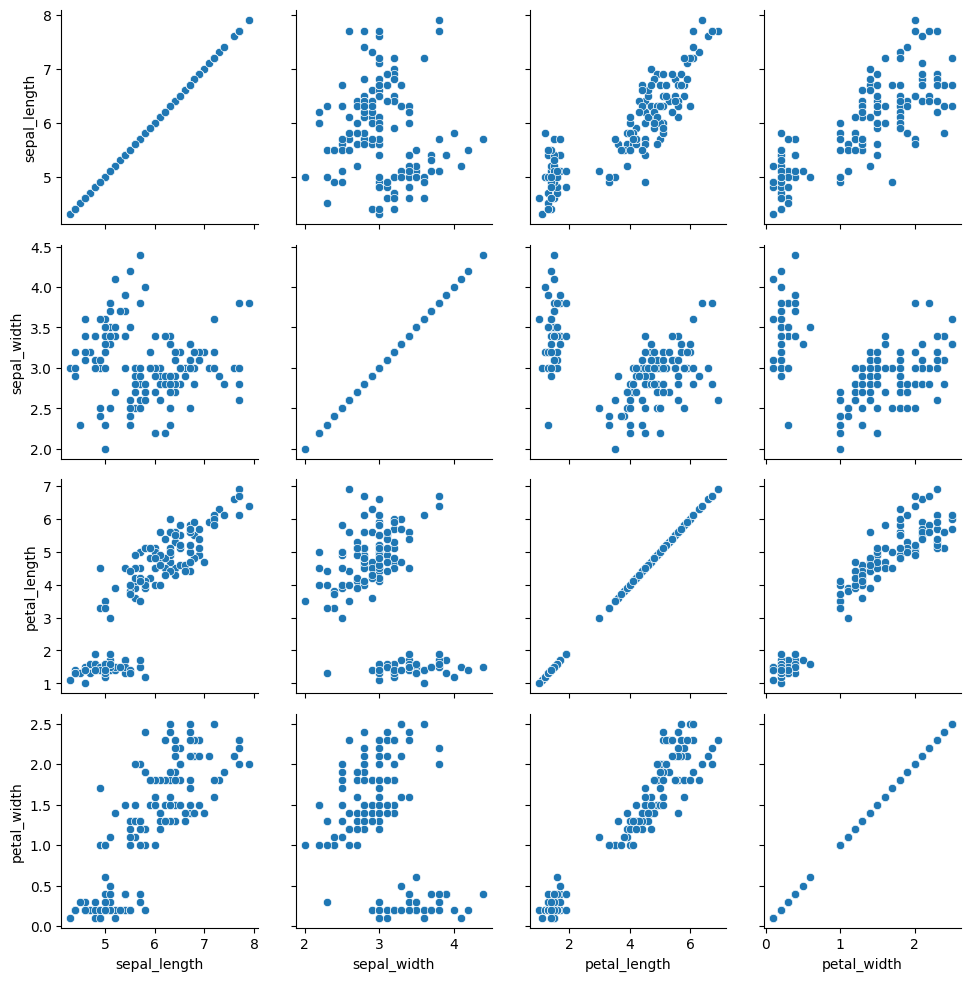

In [30]:
g = sns.PairGrid(df).map(sns.scatterplot)
plt.show()

In [72]:
epsilon = 1
min_pts = 2

## Comparison with sklearn's DBSCAN

- now that we verified that our code is running just fine and produced reasonable results, we can validate the implementation actually does what we expect it to do
- for this, we test it against a baseline implementation from which we know (or at least _assume_) that it is correct.

In [73]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
df_cluster = df.assign(cluster=dbscan.fit_predict(df))


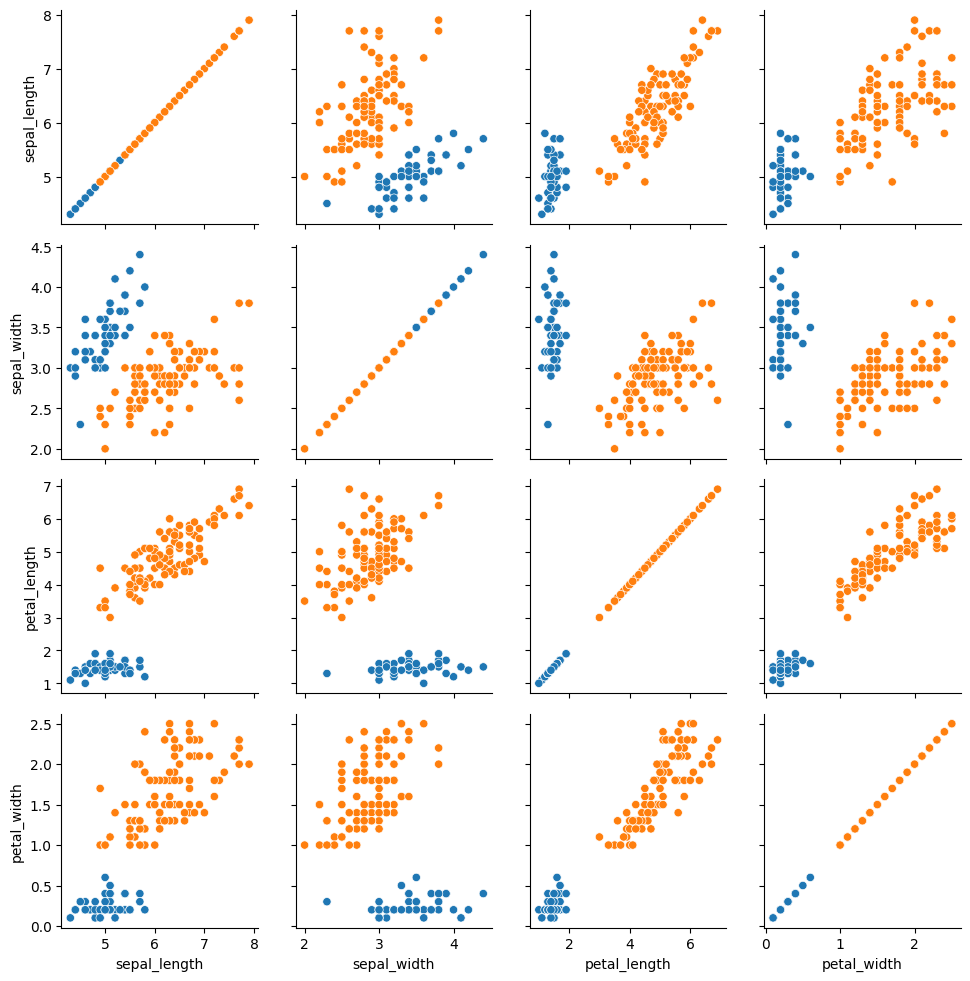

In [74]:
g = sns.PairGrid(df_cluster, hue="cluster").map(sns.scatterplot)
plt.show()